# Silicon Module Backsheet Comparison: Moisture Ingress

This notebook demonstrates how **different backsheet materials** affect moisture ingress
into the back encapsulant of a crystalline-silicon (c-Si) PV module.

## Backsheet materials compared

| Code | Material | Alias |
|------|----------|-------|
| W021 | Vectran  | LCP (Liquid Crystal Polymer) |
| W017 | Polyethylene Terephthalate (ST504) | PET-2 |
| W022 | Poly Vinyl Fluoride (Tedlar, filled) | PVF |

All three materials and the EVA encapsulant (W001) are from the **Kempe (2006)**
`H2Opermeation` database distributed with pvdeg.

> **Caveats & Sources**
> - DHEH here is used as a **relative moisture-stress metric** for comparing materials,
>   following the methodology of **Koehl et al. (2012, 2017)**.
> - The model quantifies moisture arriving at the *back encapsulant* only. It does not
>   model the subsequent degradation, e.g. through acetic acid generation and corrosion.
> - No absolute energy yield impact is presented, but **relative rankings** between
>   backsheet materials offer insight into a bill-of-materials analysis workflow.

## 1. Setup

In [1]:
# NBVAL_IGNORE_OUTPUT
import os
import json
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pvdeg

# Redirect all Scenario job folders to the system temp directory.
# Keeps the repo working directory free of pvd_job_* clutter.
pvdeg.config.SCENARIO_OUTPUT_PATH = tempfile.gettempdir()

# Repository paths
REPO_ROOT = os.path.dirname(os.path.dirname(pvdeg.__file__))
TUTORIALS_DATA = os.path.join(REPO_ROOT, "tutorials", "data")

# Backsheet materials to compare (all from H2Opermeation database)
BACKSHEETS = {
    "Vectran LCP (W021)": "W021",
    "PET-2 (ST504, W017)": "W017",
    "Tedlar PVF (W022)": "W022",
}

# Module stack physical parameters
ENCAPSULANT = "W001"  # EVA (Kempe 2006) — front and back encapsulant
BACKSHEET_THICK = 0.3  # mm — typical for PET/PVF backsheets
BACK_ENCAP_THICK = 0.46  # mm — typical for EVA back encapsulant

# IEC 61215 damp-heat reference conditions
T_DH = 85.0  # °C
RH_DH = 85.0  # %

# Gas constant
R_GAS = 8.314e-3  # kJ / (mol · K)

# DHEH model parameters (illustrative — see notebook header)
EA_DEG = 40.0  # kJ/mol  activation energy for moisture-driven degradation
N_RH = 1.0  # RH exponent (linear; Peck's model uses 2.7)

print(f"pvdeg version : {pvdeg.__version__}")
print(f"Backsheet materials : {list(BACKSHEETS.keys())}")

pvdeg version : 0.7.1.dev27+gde5391d47
Backsheet materials : ['Vectran LCP (W021)', 'PET-2 (ST504, W017)', 'Tedlar PVF (W022)']


In [2]:
LOCATIONS = {
    "Golden, CO": ("psm4_golden.csv", "meta_golden.json"),
    "Miami, FL": ("psm4_miami.csv", "meta_miami.json"),
    "New York, NY": ("psm4_nyc.csv", "meta_nyc.json"),
}

all_weather, all_meta = {}, {}
for loc, (wf, mf) in LOCATIONS.items():
    df = pd.read_csv(
        os.path.join(TUTORIALS_DATA, wf),
        index_col=0,
        parse_dates=True,
    )
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    with open(os.path.join(TUTORIALS_DATA, mf)) as _f:
        mt = json.load(_f)
    all_weather[loc], all_meta[loc] = df, mt
    print(f"  {loc}: {len(df)} rows  ({mt['latitude']:.2f}°N, {mt['longitude']:.2f}°E)")

  Golden, CO: 8760 rows  (39.73°N, -105.18°E)


  Miami, FL: 8760 rows  (25.77°N, -80.18°E)


  New York, NY: 8760 rows  (40.65°N, -73.98°E)


---
## 2. Job parameter setup

PVDeg functions are added to the pipeline via `addJob()`, and outputs from one function
are fed into another using `depends_on` in the Scenario pipeline. Shared weather-column
kwargs are defined once for surface RH. For each backsheet material, material-specific
kwargs are passed directly to `back_encapsulant_water_concentration`.

In [3]:
# Shared kwargs for RH-surface calculation
SURFACE_RH_BASE_KWARGS_BY_LOC = {
    loc: {
        "rh_ambient": all_weather[loc]["relative_humidity"],
        "temp_ambient": all_weather[loc]["temp_air"],
    }
    for loc in LOCATIONS
}

---
## 3. Scenario — backsheet material sweep

A single `Scenario` is built per location. The pipeline contains:

- **Shared upstream jobs** (run once, results forwarded via `depends_on`):
  `poa` → `temp_mod` → `rh_surface`
- **Per-material back-encapsulant job** — one `addJob` call per backsheet material,
  each producing an independent `rh_back_wXXX` result.

```
poa  →  temp_mod  →  rh_surface  →  rh_back_w021  (Vectran LCP)
                              └──→  rh_back_w017  (PET-2, ST504)
                              └──→  rh_back_w022  (Tedlar PVF)
```

In [4]:
def build_scenario(loc_name):
    """Build and run a backsheet-comparison Scenario for one location."""
    weather_df = all_weather[loc_name]
    meta = all_meta[loc_name]
    safe_loc = loc_name.replace(", ", "-").replace(" ", "")

    # POA geometry from location metadata.
    surface_tilt = float(abs(meta["latitude"]))
    surface_azimuth = 180.0 if float(meta["latitude"]) >= 0 else 0.0

    s = pvdeg.Scenario(
        name=f"si-backsheet-{safe_loc}",
        weather_data=weather_df,
        meta_data=meta,
    )

    # Register module: provides temperature model configuration.
    # Backsheet material is NOT registered here — it varies per job below.
    s.addModule(
        module_name="glass-eva-Si-eva-backsheet",
        racking="open_rack_glass_polymer",
        temperature_model="sapm",
        materials={
            "encapsulant": {
                "material_file": "H2Opermeation",
                "material_name": ENCAPSULANT,  # EVA W001
            },
        },
    )

    # Shared upstream jobs
    s.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {"surface_tilt": surface_tilt, "surface_azimuth": surface_azimuth},
        ),
        name="poa",
    )
    s.addJob(
        func=pvdeg.temperature.module,
        name="temp_mod",
        depends_on={"poa": "poa"},
    )
    s.addJob(
        func=(pvdeg.humidity.surface_relative, SURFACE_RH_BASE_KWARGS_BY_LOC[loc_name]),
        name="rh_surface",
        depends_on={"temp_module": "temp_mod"},
    )

    # Per-material back-encapsulant RH jobs
    for label, mat_code in BACKSHEETS.items():
        back_encap_kwargs = {
            "backsheet": mat_code,
            "encapsulant": ENCAPSULANT,
            "backsheet_thickness": BACKSHEET_THICK,
            "back_encap_thickness": BACK_ENCAP_THICK,
            "output": "rh",
        }

        s.addJob(
            func=(
                pvdeg.humidity.back_encapsulant_water_concentration,
                back_encap_kwargs,
            ),
            name=f"rh_back_{mat_code.lower()}",
            depends_on={
                "temp_module": "temp_mod",
                "rh_surface": "rh_surface",
            },
        )

    s.run()
    return s


# Run for Golden, CO (demo location)
s_golden = build_scenario("Golden, CO")
res_golden = s_golden.results["glass-eva-Si-eva-backsheet"]
print("Pipeline complete — Golden, CO")

Pipeline complete — Golden, CO


### 3.1 Back-encapsulant RH time series — sample week

A summer week (July 4–11) shows the diurnal cycle clearly:
module temperature peaks during the afternoon while surface RH drops, then reverses overnight.
The three backsheet materials equilibrate to different steady-state moisture levels
because of their different permeability activation energies ($E_{ap}$).

Text(0.5, 1.01, 'Backsheet material comparison — Golden, CO (July sample week)')

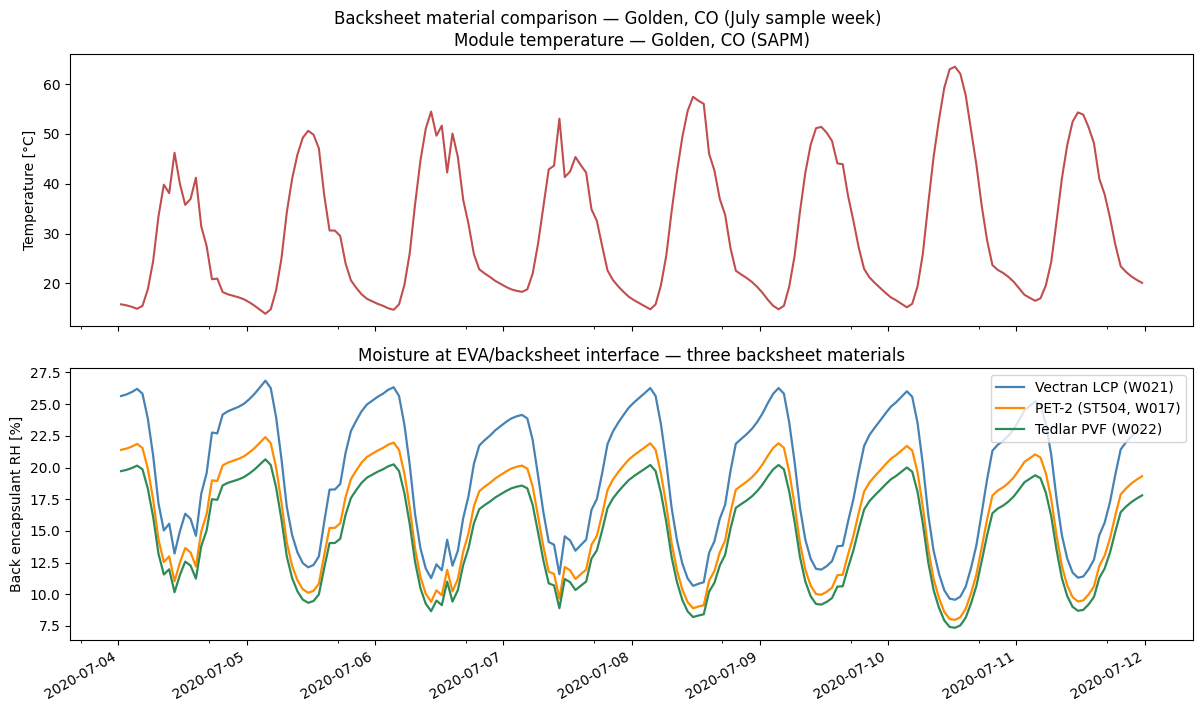

In [5]:
start, end = "2020-07-04", "2020-07-11"
temp_mod_g = res_golden["temp_mod"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Panel 1: module temperature
temp_mod_g[start:end].plot(ax=axes[0], color="firebrick", alpha=0.8)
axes[0].set_ylabel("Temperature [°C]")
axes[0].set_title("Module temperature — Golden, CO (SAPM)")

# Panel 2: back encapsulant RH for each backsheet material
colors = ["steelblue", "darkorange", "seagreen"]
for (label, mat_code), color in zip(BACKSHEETS.items(), colors):
    rh = res_golden[f"rh_back_{mat_code.lower()}"]
    rh[start:end].plot(ax=axes[1], label=label, color=color, linewidth=1.6)

axes[1].set_ylabel("Back encapsulant RH [%]")
axes[1].set_title("Moisture at EVA/backsheet interface — three backsheet materials")
axes[1].legend(loc="upper right")

fig.tight_layout()
fig.suptitle(
    "Backsheet material comparison — Golden, CO (July sample week)",
    y=1.01,
    fontsize=12,
)

---
## 4. Damp Heat Equivalent Hours (DHEH)

The DHEH metric maps real-world climate stress onto the IEC 61215 laboratory
damp-heat test conditions (85 °C, 85 % RH, 1 000 h), enabling direct comparison
across backsheet materials **and** locations. The methodology follows **Koehl et al.
(2012, 2017)**.

$$
DHEH_\text{annual}
= \sum_{t=1}^{8760}
  \underbrace{\exp\!\left[\frac{E_a}{R}\!\left(\frac{1}{T_\text{DH}}-\frac{1}{T_\text{mod}(t)}\right)\right]}_{\text{thermal acceleration}}
  \cdot
  \underbrace{\left(\frac{RH_\text{back}(t)}{RH_\text{DH}}\right)^{n}}_{\text{humidity factor}}
  \cdot \Delta t
$$

| Symbol | Value | Note |
|--------|-------|------|
| $T_\text{DH}$ | 85 + 273.15 K | IEC damp-heat temperature |
| $RH_\text{DH}$ | 85 % | IEC damp-heat humidity |
| $E_a$ | 40 kJ/mol | Representative for EVA/contact degradation; range 30–55 kJ/mol |
| $n$ | 1 | Linear RH dependence (Peck's model: 2.7) |
| $\Delta t$ | 1 h | Hourly TMY time step |

**Interpretation:** If DHEH = 100 h/year, then 1000 h of IEC damp-heat testing represents
approximately 10 years of field exposure in that location. Lower DHEH means the climate is
milder with respect to moisture stress.

**References:**
- Koehl, M., Heck, M., & Wiesmeier, S. (2012). Modelling of conditions for accelerated
  lifetime testing of humidity impact on PV-modules based on monitoring of climatic data.
  *Solar Energy Materials & Solar Cells*, **99**, 282–291.
- Koehl, M., Hoffmann, S., & Wiesmeier, S. (2017). Evaluation of damp-heat testing of
  photovoltaic modules. *Progress in Photovoltaics: Research and Applications*, **25**, 175–183.

In [6]:
# NBVAL-IGNORE-OUTPUT
dheh_golden = {}
for label, mat_code in BACKSHEETS.items():
    rh_back = res_golden[f"rh_back_{mat_code.lower()}"]
    dheh_golden[label] = pvdeg.humidity.damp_heat_equivalent_hours(
        rh_back, temp_mod_g, activation_energy=EA_DEG, rh_exponent=N_RH
    )

print("Annual DHEH and years-equivalent to 1000h IEC test — Golden, CO:")
print(f"{'Material':<35s} {'DHEH (h/yr)':<15s} {'Years per 1000h IEC'}")
print("-" * 65)
for label, dheh in dheh_golden.items():
    years_equiv = 1000.0 / dheh
    print(f"{label:<33s} {dheh:>6.1f} {years_equiv:>5.1f} years")

Annual DHEH and years-equivalent to 1000h IEC test — Golden, CO:
Material                            DHEH (h/yr)     Years per 1000h IEC
-----------------------------------------------------------------
Vectran LCP (W021)                 111.4   9.0 years
PET-2 (ST504, W017)                 93.0  10.8 years
Tedlar PVF (W022)                   85.7  11.7 years


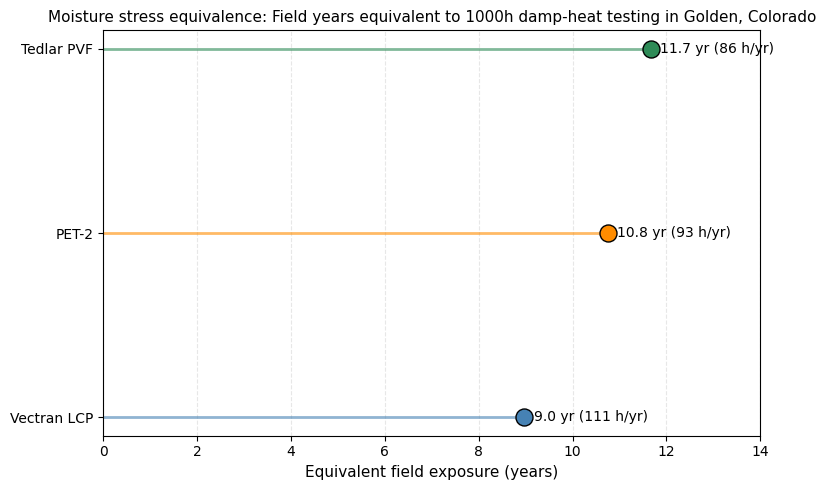

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

labels_short = [lbl.split("(")[0].strip() for lbl in dheh_golden]
values_dheh = list(dheh_golden.values())
values_years = [1000.0 / dheh for dheh in values_dheh]
colors = ["steelblue", "darkorange", "seagreen"]

y_pos = np.arange(len(labels_short))
for i, (years, dheh, color, label) in enumerate(
    zip(values_years, values_dheh, colors, labels_short)
):
    ax.plot([0, years], [i, i], color=color, linewidth=2.0, alpha=0.6)
    ax.scatter(years, i, s=150, color=color, edgecolor="black", linewidth=1.0, zorder=3)
    ax.text(
        years + 0.2, i, f"{years:.1f} yr ({dheh:.0f} h/yr)", va="center", fontsize=10
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_short)
ax.set_xlabel("Equivalent field exposure (years)", fontsize=11)
ax.set_title(
    "Moisture stress equivalence: Field years equivalent to 1000h damp-heat testing in Golden, Colorado",
    fontsize=11,
)
ax.set_xlim(0, 14)
ax.grid(axis="x", alpha=0.3, linestyle="--")

fig.tight_layout()

---
## 5. Relative moisture-stress comparison across locations

This section reports **relative moisture-stress metrics** derived directly from annual DHEH.
To avoid over-claiming from this limited three-material comparison, each material is
normalized to the **minimum observed DHEH within the compared set at each location**.

Lower values indicate less modeled moisture stress; 1.00 denotes the minimum observed
stress within that location for this specific three-material comparison.

$$
\text{Stress ratio to minimum in set} = \frac{DHEH_i}{\min_j(DHEH_j)}
$$

$$
\text{Excess stress vs minimum [\%]} = \left(\frac{DHEH_i}{\min_j(DHEH_j)} - 1\right) \times 100
$$

These metrics are dimensionless and location-specific. They permit comparative analysis
within the tested material set where absolute energy-yield and power-loss analysis is
not possible due to an absence of published models.

In [8]:
def relative_stress_metrics(dheh_by_material):
    """Compute relative moisture-stress metrics from DHEH values.

    Parameters
    ----------
    dheh_by_material : dict
        Mapping {material_label: annual_dheh_hours}.

    Returns
    -------
    dict
        Mapping {label: {"ratio_to_minimum": ..., "excess_vs_minimum_pct": ...}}
        where the reference is the minimum DHEH within the compared material set.
    """
    minimum_observed = min(dheh_by_material.values())
    metrics = {}
    for label, dheh in dheh_by_material.items():
        ratio = dheh / minimum_observed
        metrics[label] = {
            "ratio_to_minimum": ratio,
            "excess_vs_minimum_pct": (ratio - 1.0) * 100.0,
        }
    return metrics

In [9]:
# NBVAL-IGNORE-OUTPUT
scenarios_all = {"Golden, CO": s_golden}
for loc_name in LOCATIONS:
    if loc_name == "Golden, CO":
        continue
    print(f"Running Scenario: {loc_name} ...", end=" ", flush=True)
    scenarios_all[loc_name] = build_scenario(loc_name)
    print("done")

rows = []
for loc_name, scenario in scenarios_all.items():
    res = scenario.results["glass-eva-Si-eva-backsheet"]
    temp_mod = res["temp_mod"]

    dheh_by_material = {}
    for label, mat_code in BACKSHEETS.items():
        rh_back = res[f"rh_back_{mat_code.lower()}"]
        dheh_by_material[label] = pvdeg.humidity.damp_heat_equivalent_hours(
            rh_back, temp_mod, activation_energy=EA_DEG, rh_exponent=N_RH
        )

    rel_metrics = relative_stress_metrics(dheh_by_material)

    for label in BACKSHEETS:
        rows.append(
            {
                "Location": loc_name,
                "Backsheet": label.split("(")[0].strip(),
                "DHEH [h/yr]": dheh_by_material[label],
                "Stress ratio to minimum in set [-]": rel_metrics[label][
                    "ratio_to_minimum"
                ],
                "Excess stress vs minimum in set [%]": rel_metrics[label][
                    "excess_vs_minimum_pct"
                ],
            }
        )

df_summary = pd.DataFrame(rows)

Running Scenario: Miami, FL ... 

done
Running Scenario: New York, NY ... 

done


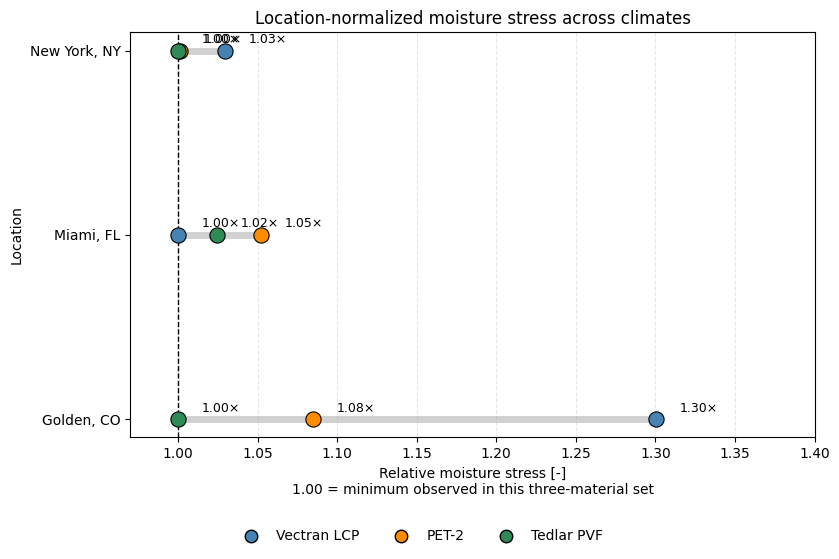

In [10]:
location_order = list(LOCATIONS.keys())
material_order = [label.split("(")[0].strip() for label in BACKSHEETS]
material_colors = dict(zip(material_order, ["steelblue", "darkorange", "seagreen"]))
y_pos = np.arange(len(location_order))

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for idx, loc in enumerate(location_order):
    loc_df = (
        df_summary[df_summary["Location"] == loc]
        .set_index("Backsheet")
        .loc[material_order]
    )

    ratio_vals = loc_df["Stress ratio to minimum in set [-]"].to_numpy()

    ax.plot(
        [1.0, ratio_vals.max()],
        [idx, idx],
        color="0.82",
        linewidth=5,
        solid_capstyle="round",
        zorder=1,
    )

    for material, ratio in zip(material_order, ratio_vals):
        color = material_colors[material]
        ax.scatter(
            ratio, idx, s=120, color=color, edgecolor="black", linewidth=0.8, zorder=3
        )
        ax.text(ratio + 0.015, idx + 0.06, f"{ratio:.2f}×", fontsize=9, va="center")

ax.set_yticks(y_pos)
ax.set_yticklabels(location_order)
ax.set_ylabel("Location")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel(
    "Relative moisture stress [-]\n1.00 = minimum observed in this three-material set"
)
ax.set_title("Location-normalized moisture stress across climates")
ax.set_xlim(
    0.97,
    df_summary["Stress ratio to minimum in set [-]"].max() + 0.1,
)
ax.grid(axis="x", alpha=0.3, linestyle="--")

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=material,
        markerfacecolor=material_colors[material],
        markeredgecolor="black",
        markersize=9,
    )
    for material in material_order
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)
fig.tight_layout(rect=(0, 0.06, 1, 1))

In [11]:
# NBVAL-IGNORE-OUTPUT
print(df_summary.round(2).set_index(["Location", "Backsheet"]).to_string())

                          DHEH [h/yr]  Stress ratio to minimum in set [-]  Excess stress vs minimum in set [%]
Location     Backsheet                                                                                        
Golden, CO   Vectran LCP       111.44                                1.30                                30.05
             PET-2              92.97                                1.08                                 8.50
             Tedlar PVF         85.69                                1.00                                 0.00
Miami, FL    Vectran LCP       557.69                                1.00                                 0.00
             PET-2             586.68                                1.05                                 5.20
             Tedlar PVF        571.24                                1.02                                 2.43
New York, NY Vectran LCP       266.77                                1.03                                 2.94
 

---
## Summary and caveats

This notebook demonstrates a backsheet comparison workflow focused on moisture-stress metrics.

### Key physical insights

A natural next step would be to model the subsequent impacts of moisture ingress on
degradation, for example through acetic acid generation in EVA → busbar corrosion → series resistance increase → power loss.
This pathway is conceptually well understood but lacks a published end-to-end kinetic model
with empirically validated rate constants.

### See also

- `07_scenario_perovskite_module_stack.ipynb` — perovskite module stack, same `addModule` / `depends_on` pattern, different absorber physics.
- `06_scenario_perovskite_ey.ipynb` — full energy yield projection for perovskite with a **complete** kinetic chain (absorber CE model → PR → $T_{90}$ lifetime).